In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cross Fusion Dual branch model

In [3]:
model_result=pd.read_csv(r"D:\coding\FYP_Project\Merge\checkpoints\DUAL_cross_branch_model\logs\CBIF-HOTR_metrics.csv")
# model_result=pd.read_csv(r"D:\coding\FYP_Project\Merge\checkpoints\DUAL_cross_branch_model26062026\logs\har_metrics.csv")
model_result.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   epoch                         60 non-null     int64  
 1   total_loss                    60 non-null     float64
 2   object_label_loss             60 non-null     float64
 3   loss_human_bbox               60 non-null     float64
 4   loss_human_giou               60 non-null     float64
 5   violence_action_loss          60 non-null     float64
 6   violence_object_loss          60 non-null     float64
 7   violence_human_loss           60 non-null     float64
 8   vcoco_action_loss             60 non-null     float64
 9   vcoco_object_loss             60 non-null     float64
 10  vcoco_human_loss              60 non-null     float64
 11  loss_HHI_action               60 non-null     float64
 12  loss_aggressor                60 non-null     float64
 13  loss_vi

In [4]:

# ----------------------------------------------------------------------
# 2. Define groups (only columns that actually exist will be plotted)
# ----------------------------------------------------------------------
groups = {
    "LOSS":["total_loss"],
    "Instance Loss": [
        "object_label_loss",
        "loss_human_bbox",
        "loss_human_giou",
    ],
    "HOI Violence head losses": [
        "violence_action_loss",
        "violence_object_loss",
        "violence_human_loss",
    ],
    "HOI V-COCO head losses": [
        "vcoco_action_loss",
        "vcoco_object_loss",
        "vcoco_human_loss",
    ],
    "HHI Violence losses": [
        "loss_HHI_action",
        "loss_aggressor",
        "loss_victim",
        "loss_visibility",
    ],
    "Detection pair recall": [
        "Detection pair recall (HOI)",
        "Detection pair recall (HHI)",
    ],
    "IoU means": [
        "iou_hoi_human_mean",
        "iou_hoi_object_mean",
        "iou_HHI_aggressor_mean",
        "iou_HHI_victim_mean",
    ],
    "Learning rate": [
        "lr",
    ],
}

In [5]:
# ----------------------------------------------------------------------
# 3. Plot each group as its own figure (saved + shown)
# ----------------------------------------------------------------------
plt.rcParams.update({
    "figure.figsize": (9, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "lines.linewidth": 1.8,
})

In [6]:

def _normalize(name: str) -> str:
    """Lowercase + collapse whitespace + normalize spacing around parens,
    so small naming differences (extra/missing space, different case, etc.)
    still match."""
    s = " ".join(str(name).strip().lower().split())
    s = s.replace(" (", "(").replace("( ", "(").replace(" )", ")")
    return s

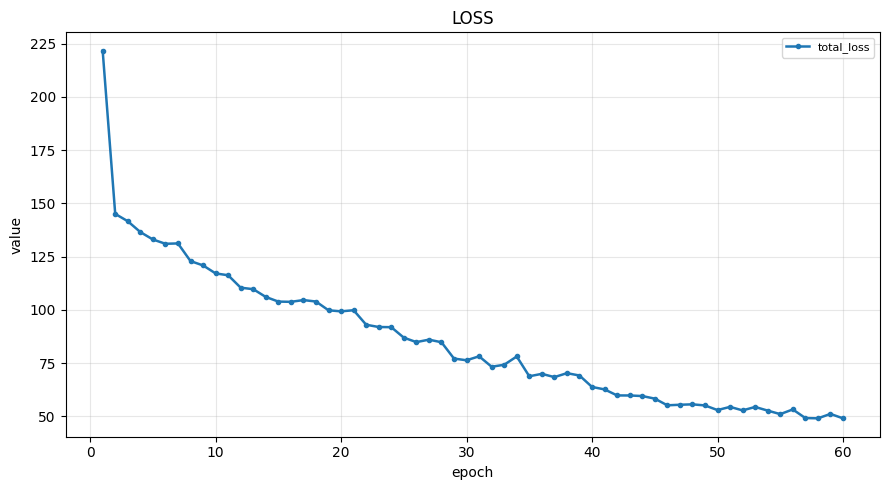

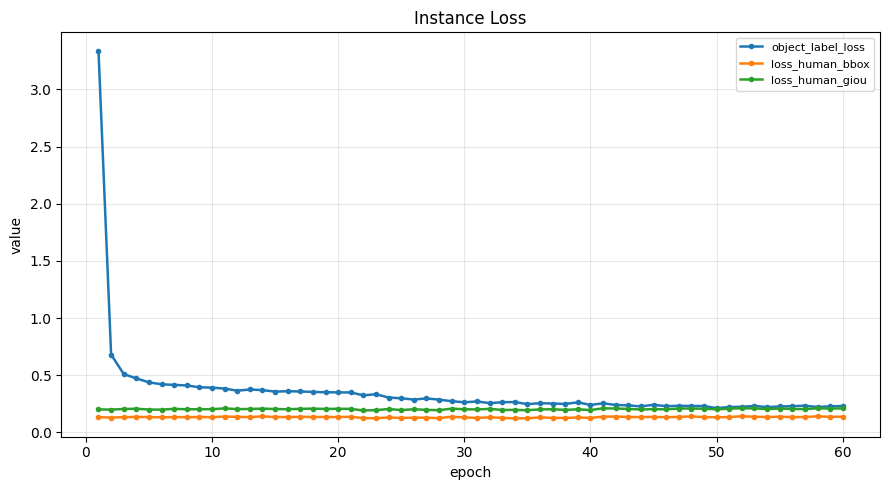

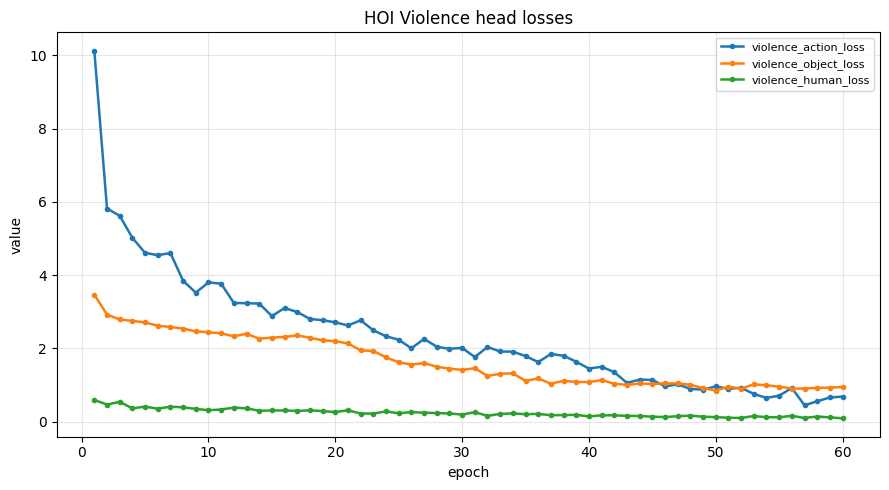

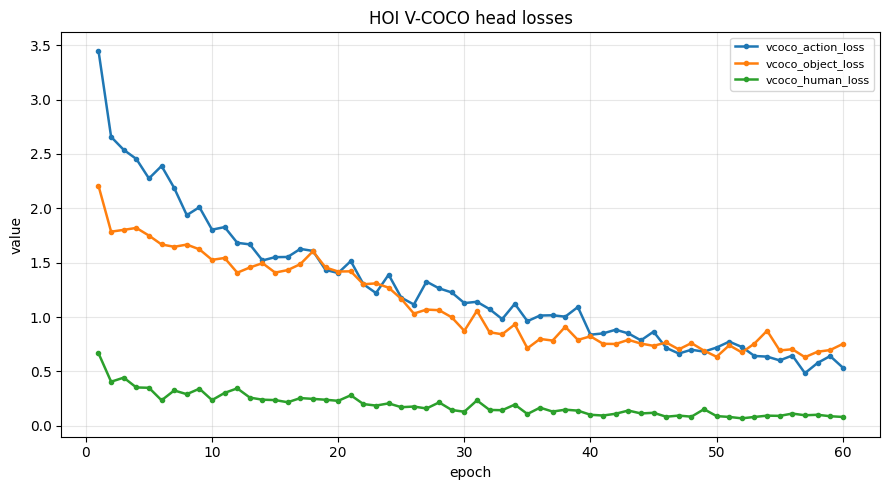

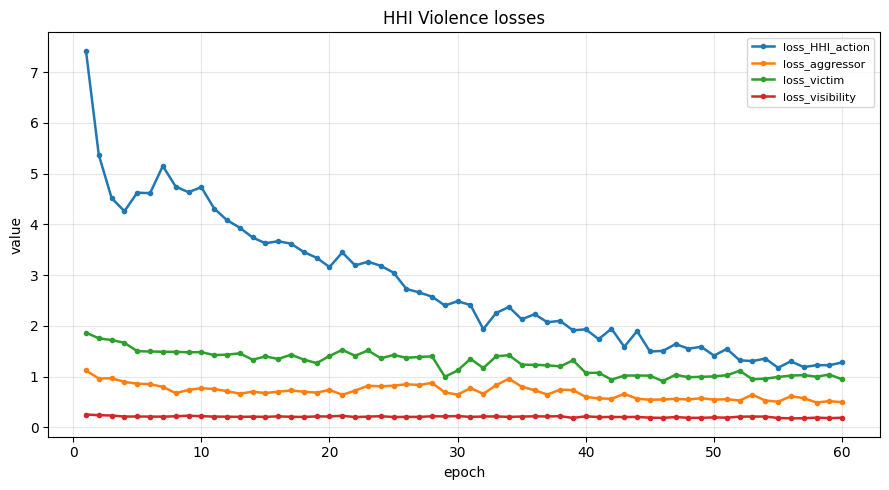

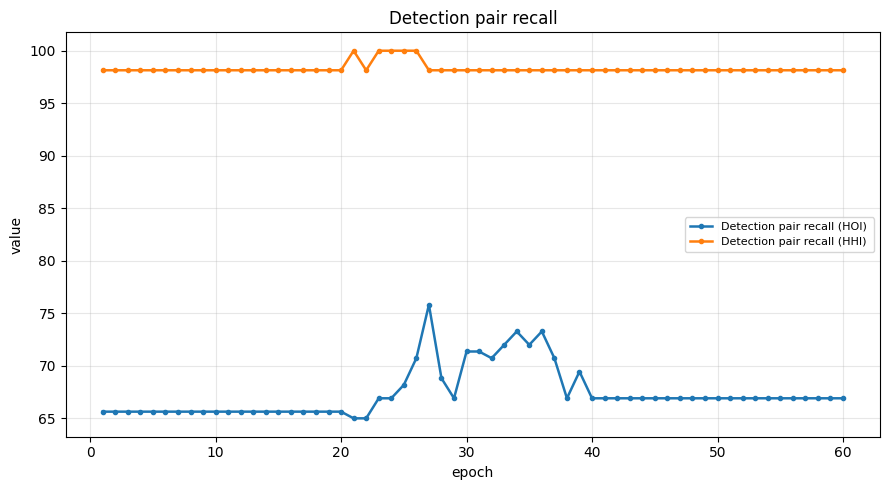

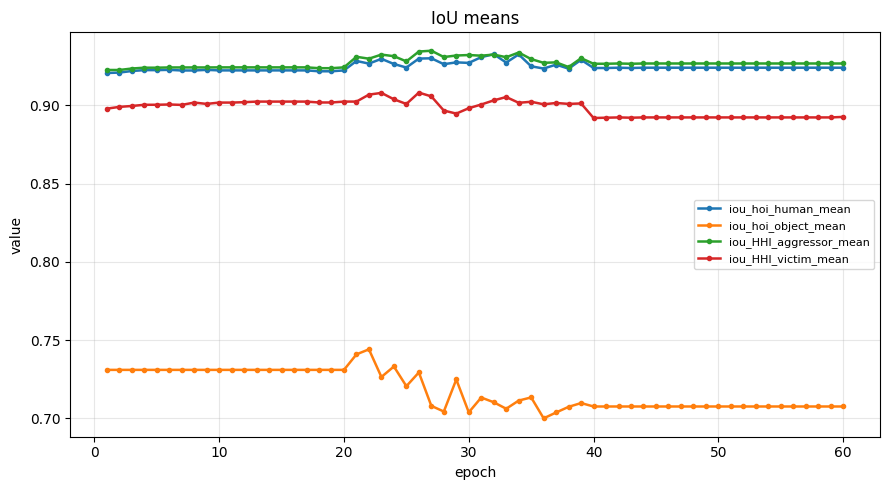

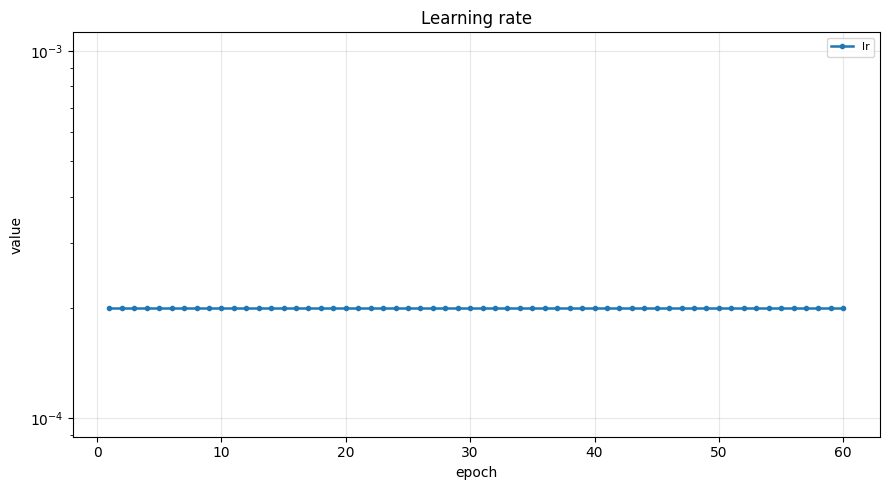

In [7]:

# Map normalized actual column name -> real column name in model_result
norm_to_real = {_normalize(c): c for c in model_result.columns}
 
for title, cols in groups.items():
    cols_present = []
    missing = []
    for c in cols:
        real = norm_to_real.get(_normalize(c))
        if real is not None:
            cols_present.append(real)
        else:
            missing.append(c)
    if missing:
        print(f"[warn] '{title}': missing columns skipped -> {missing}")
    if not cols_present:
        continue
 
    fig, ax = plt.subplots()
    for col in cols_present:
        ax.plot(model_result["epoch"], model_result[col], marker="o", markersize=3, label=col)
 
    ax.set_title(title)
    ax.set_xlabel("epoch")
    ax.set_ylabel("value")
 
    # Learning rate often spans orders of magnitude -> log scale reads better
    if title == "Learning rate":
        ax.set_yscale("log")
 
    ax.legend(loc="best", fontsize=8)
    fig.tight_layout()
 
    # out_name = title.lower().replace(" ", "_").replace("(", "").replace(")", "").replace(",", "").replace("/", "_") + ".png"
    # fig.savefig(out_name, dpi=150)
    # print(f"saved: {out_name}")
 
plt.show()

In [8]:
newdata = model_result[[
    "epoch", 
    "Scenario1_HOIvcoco", 
    "Scenario2_HOIvcoco", 
    "Scenario1_HOIviolence", 
    "Scenario2_HOIviolence", 
    "Scenario1_HHI", 
    "Scenario2_HHI"
]]
a="mAP in different scenario"
print(newdata.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   epoch                  60 non-null     int64  
 1   Scenario1_HOIvcoco     60 non-null     float64
 2   Scenario2_HOIvcoco     60 non-null     float64
 3   Scenario1_HOIviolence  60 non-null     float64
 4   Scenario2_HOIviolence  60 non-null     float64
 5   Scenario1_HHI          60 non-null     float64
 6   Scenario2_HHI          60 non-null     float64
dtypes: float64(6), int64(1)
memory usage: 3.4 KB
None


In [17]:
print(newdata.tail(3))

    epoch  Scenario1_HOIvcoco  Scenario2_HOIvcoco  Scenario1_HOIviolence  \
57     58           25.571708           25.571708              22.322124   
58     59           22.186102           22.186102              22.968134   
59     60           23.606447           23.606447              23.750157   

    Scenario2_HOIviolence  Scenario1_HHI  Scenario2_HHI  
57              22.322124      37.464099      40.457862  
58              22.968134      31.252388      34.067862  
59              23.750157      37.788282      40.297702  


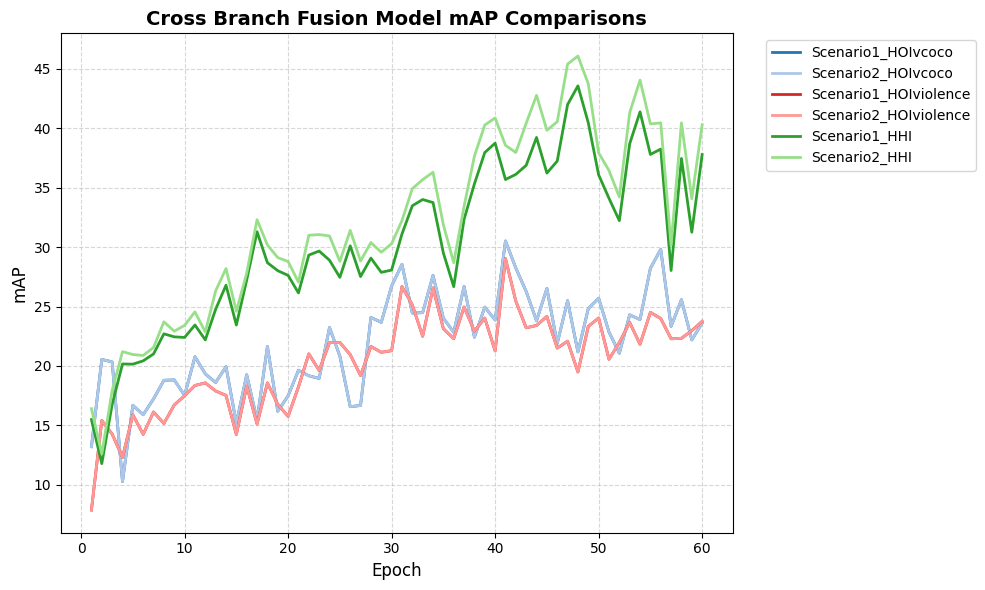

In [9]:
# 1. Initialize the plot using subplots (specifying the figure size)
fig, ax = plt.subplots(figsize=(10, 6))

# 2. Define a manual color mapping for each column
# Same section gets the same color family, but Scenario 1 is dark and Scenario 2 is light.
color_mapping = {
    "Scenario1_HOIvcoco": "#1f77b4",     # Dark Blue
    "Scenario2_HOIvcoco": "#aec7e8",     # Light Blue
    
    "Scenario1_HOIviolence": "#d62728",  # Dark Red
    "Scenario2_HOIviolence": "#ff9896",  # Light Red
    
    "Scenario1_HHI": "#2ca02c",          # Dark Green
    "Scenario2_HHI": "#98df8a"           # Light Green
}

# 3. Plot each metric column against the epoch column
for column_name, color_hex in color_mapping.items():
    ax.plot(
        model_result["epoch"], 
        model_result[column_name], 
        label=column_name, 
        color=color_hex, 
        linewidth=2
    )

# 4. Enhance formatting and labels
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("mAP", fontsize=12)
ax.set_title("Cross Branch Fusion Model mAP Comparisons", fontsize=14, fontweight="bold")

# Add a dashed background grid for better readability
ax.grid(True, linestyle="--", alpha=0.5)

# Place the legend neatly outside the plot area to avoid covering lines
ax.legend(bbox_to_anchor=(1.04, 1), loc="upper left", fontsize=10)

# 5. Adjust layout and save the visualization
plt.tight_layout()
# plt.savefig("map_scenarios_comparison.png", dpi=300)

# Independent Dual Branch Model

In [10]:
Independent_model_result=pd.read_csv(r"D:\coding\FYP_Project\Merge\checkpoints\DUAL_indepent_branch_model\logs\CBIF-HOTR_metrics.csv")
Independent_model_result.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   epoch                         60 non-null     int64  
 1   total_loss                    60 non-null     float64
 2   object_label_loss             60 non-null     float64
 3   loss_human_bbox               60 non-null     float64
 4   loss_human_giou               60 non-null     float64
 5   violence_action_loss          60 non-null     float64
 6   violence_object_loss          60 non-null     float64
 7   violence_human_loss           60 non-null     float64
 8   vcoco_action_loss             60 non-null     float64
 9   vcoco_object_loss             60 non-null     float64
 10  vcoco_human_loss              60 non-null     float64
 11  loss_HHI_action               60 non-null     float64
 12  loss_aggressor                60 non-null     float64
 13  loss_vi

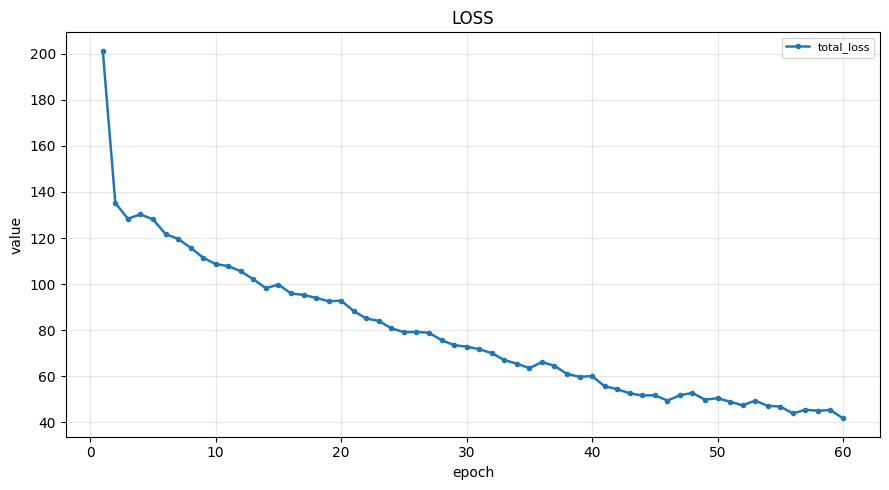

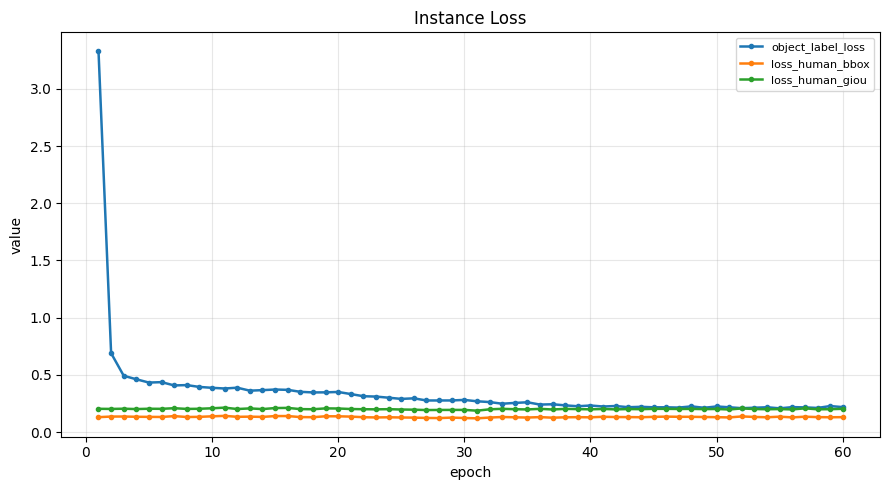

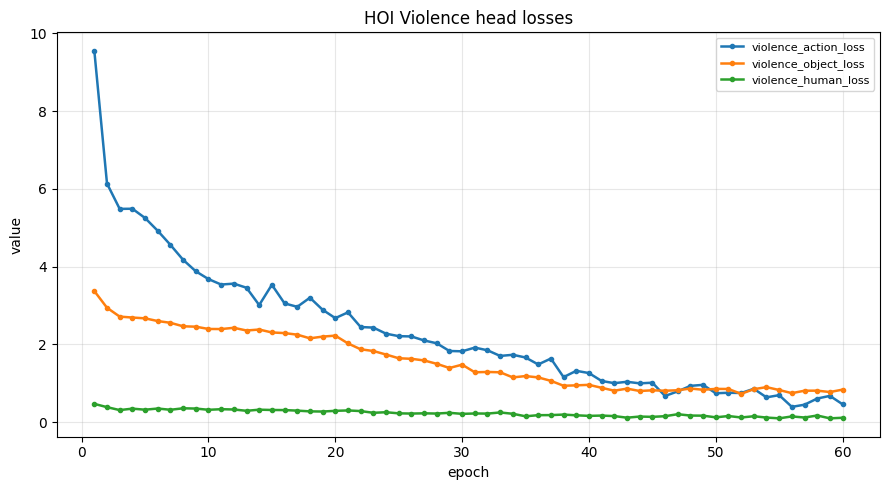

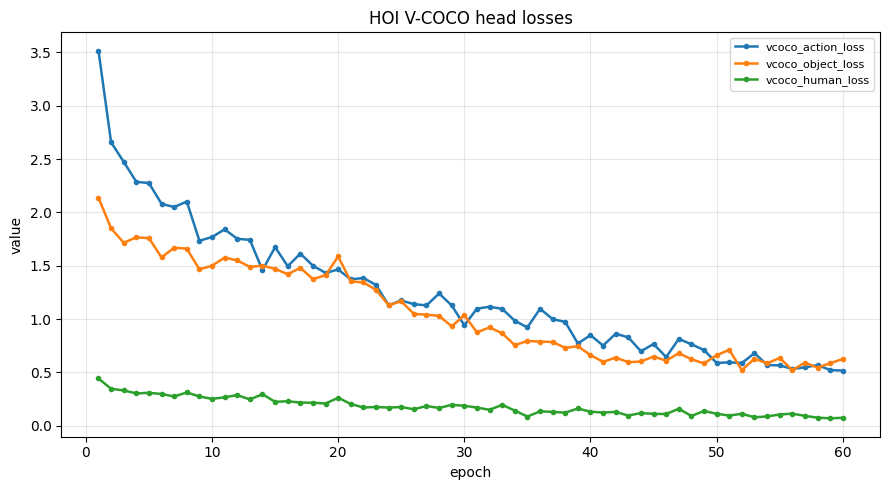

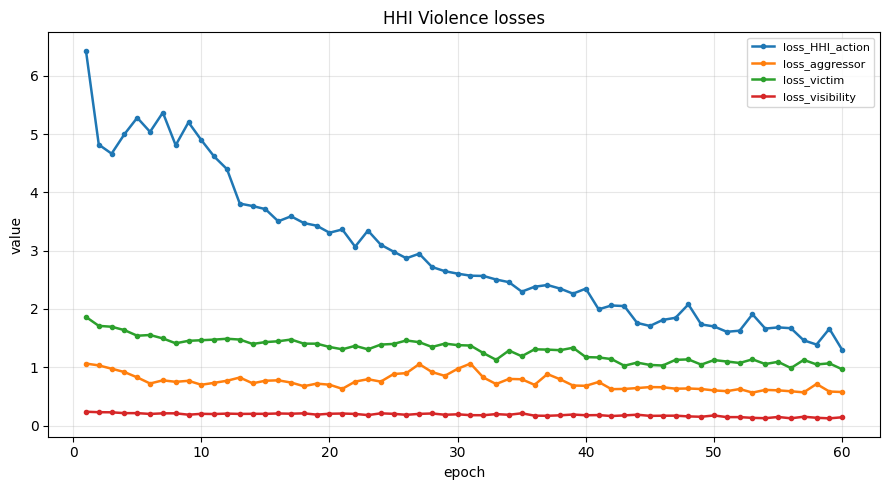

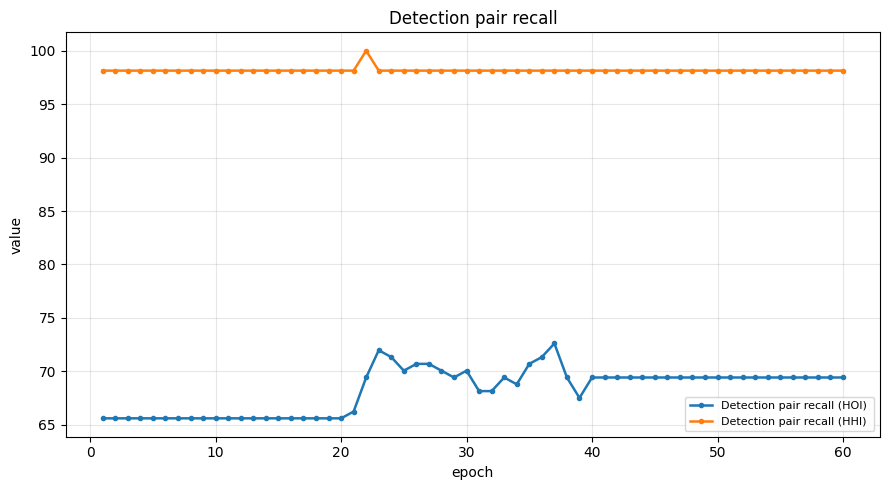

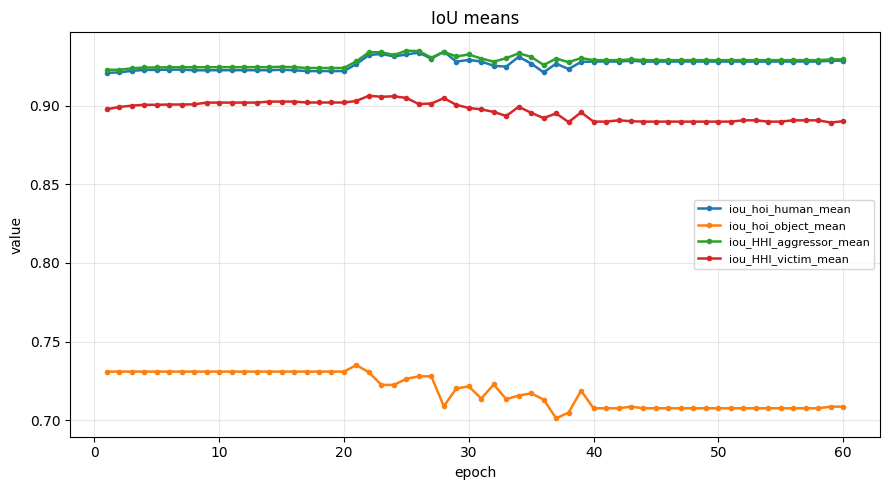

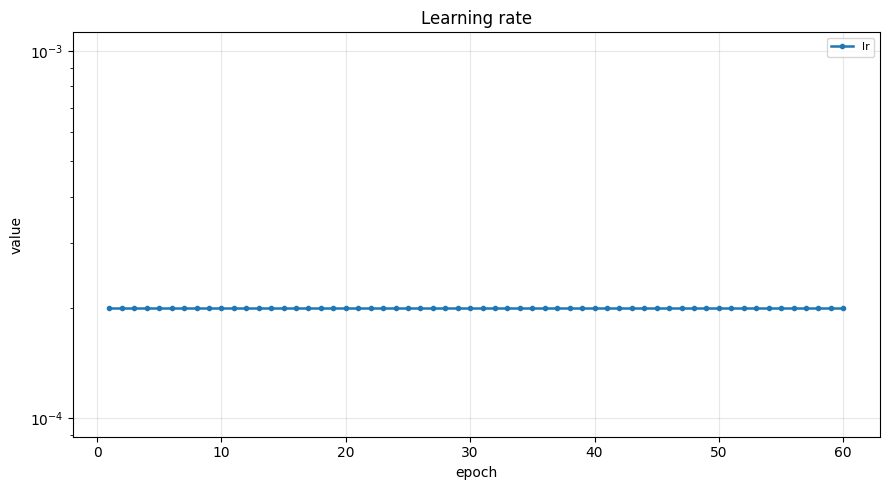

In [11]:

# Map normalized actual column name -> real column name in Independent_model_result
norm_to_real = {_normalize(c): c for c in Independent_model_result.columns}
 
for title, cols in groups.items():
    cols_present = []
    missing = []
    for c in cols:
        real = norm_to_real.get(_normalize(c))
        if real is not None:
            cols_present.append(real)
        else:
            missing.append(c)
    if missing:
        print(f"[warn] '{title}': missing columns skipped -> {missing}")
    if not cols_present:
        continue
 
    fig, ax = plt.subplots()
    for col in cols_present:
        ax.plot(Independent_model_result["epoch"], Independent_model_result[col], marker="o", markersize=3, label=col)
 
    ax.set_title(title)
    ax.set_xlabel("epoch")
    ax.set_ylabel("value")
 
    # Learning rate often spans orders of magnitude -> log scale reads better
    if title == "Learning rate":
        ax.set_yscale("log")
 
    ax.legend(loc="best", fontsize=8)
    fig.tight_layout()
 
    # out_name = title.lower().replace(" ", "_").replace("(", "").replace(")", "").replace(",", "").replace("/", "_") + ".png"
    # fig.savefig(out_name, dpi=150)
    # print(f"saved: {out_name}")
 
plt.show()

In [12]:
newdata2 = Independent_model_result[[
    "epoch", 
    "Scenario1_HOIvcoco", 
    "Scenario2_HOIvcoco", 
    "Scenario1_HOIviolence", 
    "Scenario2_HOIviolence", 
    "Scenario1_HHI", 
    "Scenario2_HHI"
]]
a="mAP in different scenario"
print(newdata2.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   epoch                  60 non-null     int64  
 1   Scenario1_HOIvcoco     60 non-null     float64
 2   Scenario2_HOIvcoco     60 non-null     float64
 3   Scenario1_HOIviolence  60 non-null     float64
 4   Scenario2_HOIviolence  60 non-null     float64
 5   Scenario1_HHI          60 non-null     float64
 6   Scenario2_HHI          60 non-null     float64
dtypes: float64(6), int64(1)
memory usage: 3.4 KB
None


In [16]:
print(newdata2.tail(3))

    epoch  Scenario1_HOIvcoco  Scenario2_HOIvcoco  Scenario1_HOIviolence  \
57     58           23.296413           23.296413              22.639155   
58     59           24.752568           24.752568              20.346741   
59     60           24.456310           24.456310              21.581316   

    Scenario2_HOIviolence  Scenario1_HHI  Scenario2_HHI  
57              22.639155      32.169307      34.522158  
58              20.346741      31.889673      34.670942  
59              21.581316      30.424405      32.782970  


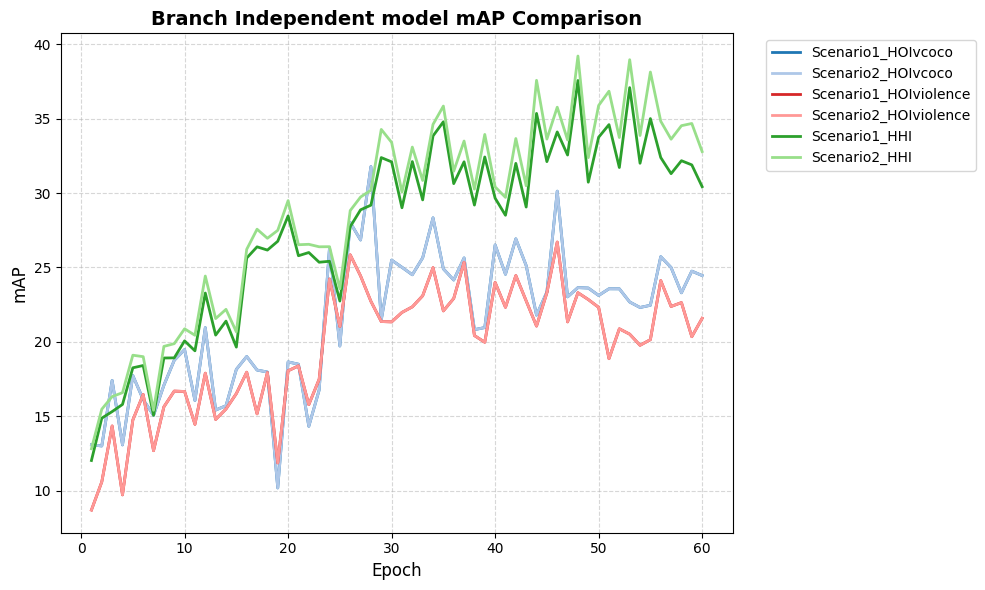

In [13]:
# 1. Initialize the plot using subplots (specifying the figure size)
fig, ax = plt.subplots(figsize=(10, 6))

# 2. Define a manual color mapping for each column
# Same section gets the same color family, but Scenario 1 is dark and Scenario 2 is light.
color_mapping = {
    "Scenario1_HOIvcoco": "#1f77b4",     # Dark Blue
    "Scenario2_HOIvcoco": "#aec7e8",     # Light Blue
    
    "Scenario1_HOIviolence": "#d62728",  # Dark Red
    "Scenario2_HOIviolence": "#ff9896",  # Light Red
    
    "Scenario1_HHI": "#2ca02c",          # Dark Green
    "Scenario2_HHI": "#98df8a"           # Light Green
}

# 3. Plot each metric column against the epoch column
for column_name, color_hex in color_mapping.items():
    ax.plot(
        Independent_model_result["epoch"], 
        Independent_model_result[column_name], 
        label=column_name, 
        color=color_hex, 
        linewidth=2
    )

# 4. Enhance formatting and labels
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("mAP", fontsize=12)
ax.set_title("Branch Independent model mAP Comparison", fontsize=14, fontweight="bold")

# Add a dashed background grid for better readability
ax.grid(True, linestyle="--", alpha=0.5)

# Place the legend neatly outside the plot area to avoid covering lines
ax.legend(bbox_to_anchor=(1.04, 1), loc="upper left", fontsize=10)

# 5. Adjust layout and save the visualization
plt.tight_layout()
# plt.savefig("map_scenarios_comparison.png", dpi=300)